<a href="https://colab.research.google.com/github/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/blob/main/Aula_APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Integrantes**

Felipe Pereira Restivo - RM: 570712

Gabriel Rodrigues Zappelloni - RM: 572060

Kenichi Caio Yamamoto - RM: 569815

Maykon de Lima Silva – RM: 574022

Rodger Costa Rios - RM: 571438

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [15]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [16]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [17]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

API ANEEL: consulta pública, sem token


In [23]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

RuntimeError: Não foi possível consultar a API: <urlopen error timed out>

In [29]:
import pandas as pd

dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')

sigla_por_fonte = {"Solar": "UFV", "Eólica": "EOL", "Hidráulica": "UHE"}

registros_aneel = [
    {
        "MdaPotenciaOutorgadaKw": linha["potencia_kw"],
        "NumCoordNEmpreendimento": linha["latitude"],
        "NumCoordEEmpreendimento": linha["longitude"],
        "SigTipoGeracao": sigla_por_fonte[linha["fonte"]],
    }
    for _, linha in dados.iterrows()
]

print("Total de linhas carregadas:", len(registros_aneel))
dados.head(20)

Total de linhas carregadas: 3876


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [25]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [26]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

Salvo: aneel_classificacao_orange.csv


### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
# Caso a consulta da API falhar:
dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
dados.head(20)

,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar
5,404.80,-12.945833,-38.417778,Solar
6,1082.00,-22.815833,-47.059167,Solar
7,1.70,-27.447981,-48.501745,Solar
8,1.04,-22.172160,-47.337620,Solar
9,30.87,-2.474278,-43.574217,Solar


### 1. Carregamento e exploração dos dados

In [33]:
dados = pd.read_csv("aneel_classificacao_orange.csv")

print("Dimensões:", dados.shape)
print("\nTipos:\n", dados.dtypes)
print("\nValores ausentes:\n", dados.isna().sum())
print("\nDistribuição das classes:\n", dados["fonte"].value_counts())
dados.describe()

Dimensões: (3876, 4)

Tipos:
 potencia_kw    float64
latitude       float64
longitude      float64
fonte           object
dtype: object

Valores ausentes:
 potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64

Distribuição das classes:
 fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


,potencia_kw,latitude,longitude
count,3.876000e+03,3876.000000,3876.000000
mean,4.201468e+04,-12.693951,-46.158299
std,3.016366e+05,9.500523,8.357453
min,1.600000e-01,-33.722806,-69.941389
25%,4.400000e+02,-21.142110,-52.561817
50%,1.268000e+04,-10.469532,-47.393697
75%,3.000000e+04,-4.127788,-41.280013
max,1.123310e+07,3.831392,0.000000


In [34]:
coord_invalida = (dados["latitude"] == 0) & (dados["longitude"] == 0)
print("Registros com coordenada (0, 0):", coord_invalida.sum())

dados = dados[~coord_invalida].reset_index(drop=True)
print("Registros após limpeza:", len(dados))
print(dados["fonte"].value_counts())

Registros com coordenada (0, 0): 47
Registros após limpeza: 3829
fonte
Hidráulica    1453
Solar         1200
Eólica        1176
Name: count, dtype: int64


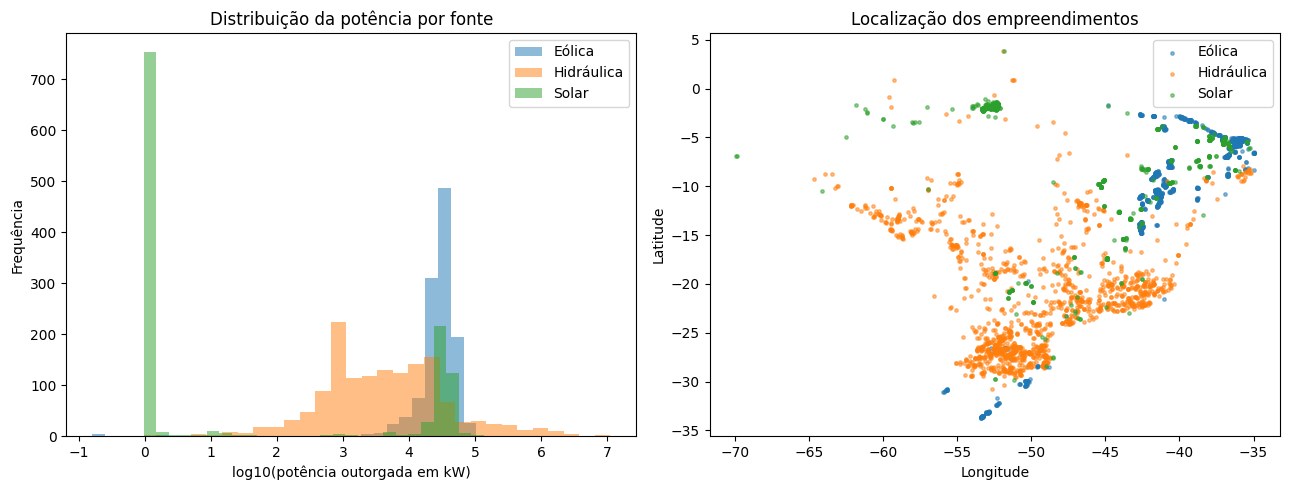

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for fonte, grupo in dados.groupby("fonte"):
    axes[0].hist(np.log10(grupo["potencia_kw"]), bins=30, alpha=0.5, label=fonte)
    axes[1].scatter(grupo["longitude"], grupo["latitude"], s=6, alpha=0.5, label=fonte)

axes[0].set_xlabel("log10(potência outorgada em kW)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da potência por fonte")
axes[0].legend()

axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_title("Localização dos empreendimentos")
axes[1].legend()

plt.tight_layout()
plt.show()

**Definição de X e y**

As entradas (`X`) são três atributos numéricos: `potencia_kw`, a potência outorgada do empreendimento em kW (capacidade autorizada, não energia produzida), e `latitude` e `longitude`, a localização aproximada em graus decimais. O alvo (`y`) é `fonte`, variável categórica com três classes: Solar, Eólica e Hidráulica (esta última agrupa UHE, PCH e CGH).

Atributos como sigla, código CEG e nome do empreendimento foram excluídos de `X`, pois revelam diretamente a classe. A potência apresenta forte assimetria, variando de frações de kW a milhões de kW, e por isso foi visualizada em escala logarítmica. Os registros com coordenadas (0, 0) foram removidos por não corresponderem a localizações reais no território brasileiro.

### 2. Divisão estratificada em treino e teste

Os dados foram divididos em 80% para treino e 20% para teste, com estratificação pela classe `fonte` e semente fixa (`random_state=42`), preservando a proporção das classes nos dois conjuntos. Ajustes de escala são aprendidos exclusivamente no treino, por meio de `Pipeline`.

In [36]:
X = dados[["potencia_kw", "latitude", "longitude"]]
y = dados["fonte"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Treino:", X_treino.shape, "| Teste:", X_teste.shape)
print("\nProporção das classes no teste:\n", y_teste.value_counts(normalize=True).round(3))

Treino: (3063, 3) | Teste: (766, 3)

Proporção das classes no teste:
 fonte
Hidráulica    0.380
Solar         0.313
Eólica        0.307
Name: proportion, dtype: float64


### 3. Escolha e treinamento dos classificadores

Foram selecionados três algoritmos com mecanismos de decisão distintos:

- **KNN (k = 5):** classifica cada empreendimento pela classe predominante entre os cinco vizinhos mais próximos. É adequado a um problema em que a proximidade geográfica tende a indicar o mesmo tipo de fonte. Por depender de distâncias, exige padronização das variáveis.
- **Regressão Logística:** modelo linear que estima a probabilidade de cada classe. Serve como referência de baixa complexidade e mostra até que ponto as classes podem ser separadas por fronteiras lineares. Também foi aplicada após padronização.
- **Random Forest (200 árvores):** conjunto de árvores de decisão treinadas sobre amostras distintas dos dados. Captura relações não lineares e interações entre potência e localização, é robusto à assimetria da potência e dispensa padronização.

A padronização foi incluída em um `Pipeline`, garantindo que média e desvio padrão sejam calculados apenas com os dados de treino.

In [41]:
classificadores = {
    "KNN (k=5)": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Regressão Logística": Pipeline([
        ("escala", StandardScaler()),
        ("modelo", LogisticRegression(max_iter=1000)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

previsoes_clf = {}
for nome, modelo in classificadores.items():
    modelo.fit(X_treino, y_treino)
    previsoes_clf[nome] = modelo.predict(X_teste)
    print(f"{nome}: treinado")

KNN (k=5): treinado
Regressão Logística: treinado
Random Forest: treinado


### 4. Comparação das métricas

As métricas Precision, Recall e F1 foram calculadas com **média macro**, que atribui o mesmo peso às três classes, independentemente do número de exemplos de cada uma. Todos os modelos foram avaliados sobre o mesmo conjunto de teste.

In [42]:
resultados_clf = []
for nome, y_pred in previsoes_clf.items():
    resultados_clf.append({
        "Modelo": nome,
        "Accuracy": accuracy_score(y_teste, y_pred),
        "Precision (macro)": precision_score(y_teste, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_teste, y_pred, average="macro"),
        "F1 (macro)": f1_score(y_teste, y_pred, average="macro"),
    })

tabela_clf = pd.DataFrame(resultados_clf).set_index("Modelo").round(3)
tabela_clf

,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
KNN (k=5),0.960,0.960,0.959,0.959
Regressão Logística,0.830,0.837,0.829,0.826
Random Forest,0.977,0.977,0.976,0.977


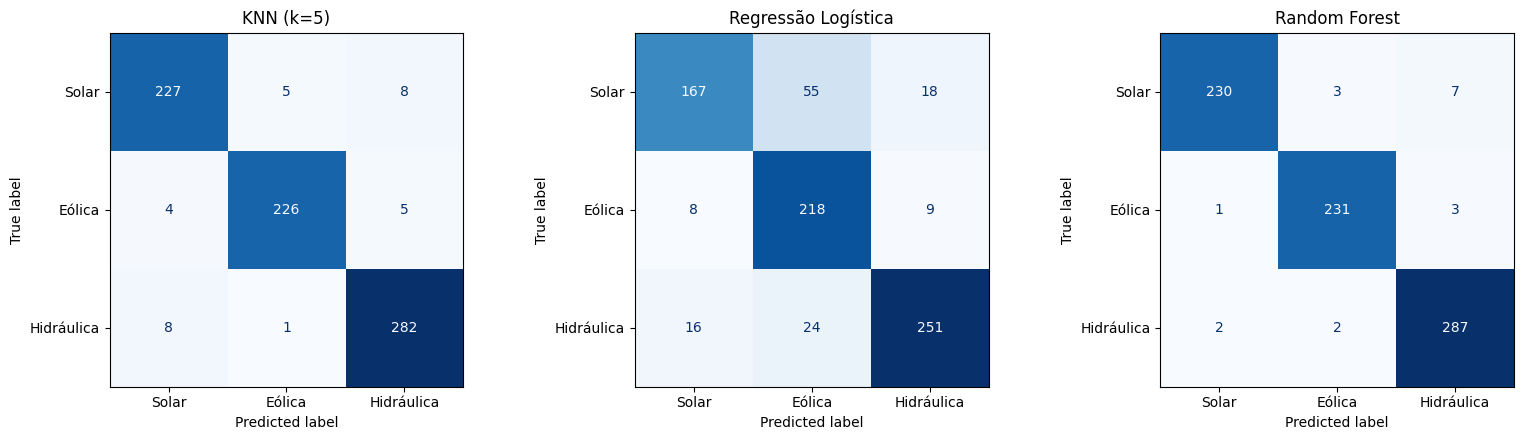

Relatório detalhado — Random Forest

              precision    recall  f1-score   support

      Eólica      0.979     0.983     0.981       235
  Hidráulica      0.966     0.986     0.976       291
       Solar      0.987     0.958     0.973       240

    accuracy                          0.977       766
   macro avg      0.977     0.976     0.977       766
weighted avg      0.977     0.977     0.976       766



In [45]:
classes = ["Solar", "Eólica", "Hidráulica"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, (nome, y_pred) in zip(axes, previsoes_clf.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, y_pred, labels=classes, ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(nome)

plt.tight_layout()
plt.show()

print("Relatório detalhado — Random Forest\n")
print(classification_report(y_teste, previsoes_clf["Random Forest"], digits=3))

### 5. Interpretação e conclusões

O **Random Forest** obteve o melhor desempenho (Accuracy 0,977; F1 macro 0,977) e seria o modelo escolhido, seguido de perto pelo KNN (F1 macro 0,959). Ambos capturam fronteiras de decisão não lineares, compatíveis com a distribuição geográfica das fontes. A **Regressão Logística** ficou bem abaixo (F1 macro 0,826), pois suas fronteiras lineares não acompanham esse padrão espacial. Sua principal confusão foi classificar empreendimentos **solares como eólicos**, fontes que se sobrepõem na faixa de potência e na região (interior do Nordeste). No Random Forest, os poucos erros restantes concentram-se na classe Solar, cujo recall (0,958) foi o menor entre as classes.

A tarefa tem limitações. Potência e localização são características indiretas da fonte, e o bom resultado reflete padrões regionais do cadastro, não uma relação física generalizável. Um novo parque solar em uma região tradicionalmente eólica tenderia a ser classificado de forma errada. Além disso, a amostra foi limitada a cerca de 1.200 registros por sigla, de modo que a distribuição das classes não representa a participação das fontes na matriz elétrica brasileira. Foram removidos 47 registros com coordenadas (0, 0), considerados inválidos.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [46]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

Open-Meteo: consulta pública, sem token


In [47]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']
Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}
Quantidade de horários: 2184


### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [48]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [49]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

Salvo: meteo_regressao_orange.csv


### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

### 1. Carregamento e exploração dos dados

In [50]:
meteo = pd.read_csv("meteo_regressao_orange.csv")
meteo["data_hora"] = pd.to_datetime(meteo["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)

print("Dimensões:", meteo.shape)
print("Período:", meteo["data_hora"].min(), "→", meteo["data_hora"].max())
print("\nTipos:\n", meteo.dtypes)
print("\nValores ausentes:\n", meteo.isna().sum())
meteo.describe()

Dimensões: (1001, 7)
Período: 2025-04-01 07:00:00 → 2025-06-30 17:00:00

Tipos:
 data_hora        datetime64[ns]
temperatura_c           float64
umidade_pct               int64
nuvens_pct                int64
vento_kmh               float64
hora                      int64
radiacao_w_m2           float64
dtype: object

Valores ausentes:
 data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
count,1001,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000,1001.000000
mean,2025-05-16 11:59:59.999999744,28.885914,50.544456,55.108891,15.465435,12.000000,472.854146
min,2025-04-01 07:00:00,19.500000,21.000000,0.000000,2.300000,7.000000,13.000000
25%,2025-04-23 15:00:00,26.300000,38.000000,19.000000,12.200000,9.000000,250.000000
50%,2025-05-16 12:00:00,29.100000,49.000000,54.000000,15.400000,12.000000,466.000000
75%,2025-06-08 09:00:00,31.700000,61.000000,98.000000,19.000000,15.000000,696.000000
max,2025-06-30 17:00:00,36.100000,95.000000,100.000000,30.100000,17.000000,1002.000000
std,NaN,3.656514,15.913965,37.851461,4.923631,3.163858,256.368950


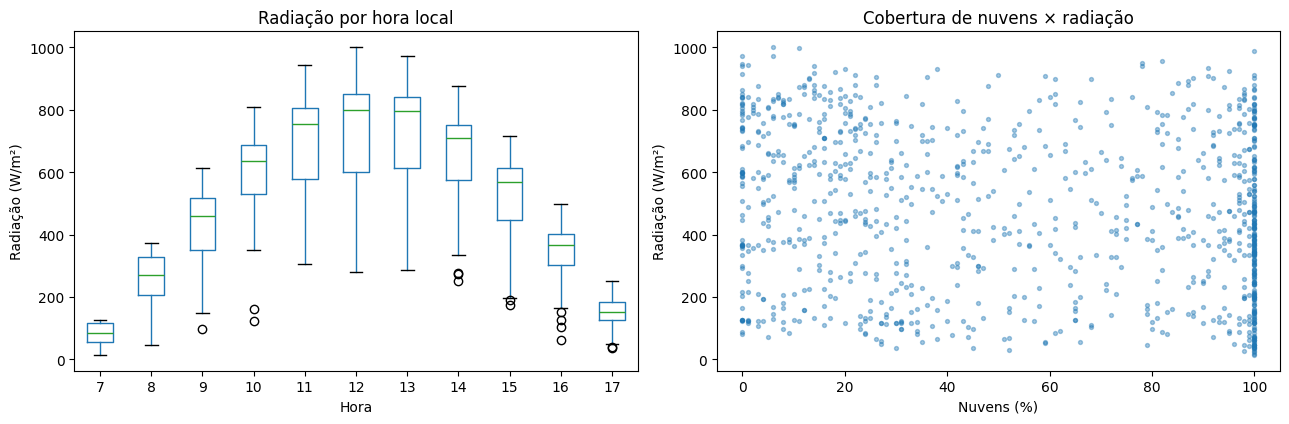

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

meteo.boxplot(column="radiacao_w_m2", by="hora", ax=axes[0], grid=False)
axes[0].set_title("Radiação por hora local")
axes[0].set_xlabel("Hora")
axes[0].set_ylabel("Radiação (W/m²)")

axes[1].scatter(meteo["nuvens_pct"], meteo["radiacao_w_m2"], s=8, alpha=0.4)
axes[1].set_title("Cobertura de nuvens × radiação")
axes[1].set_xlabel("Nuvens (%)")
axes[1].set_ylabel("Radiação (W/m²)")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Definição de X e y**

Cada linha representa uma hora local entre 7h e 17h em Petrolina (PE), de 1º de abril a 30 de junho de 2025. As entradas (`X`) são cinco atributos: `temperatura_c` (°C), `umidade_pct` (%), `nuvens_pct` (%), `vento_kmh` (km/h) e `hora` (hora local). O alvo (`y`) é `radiacao_w_m2`, a radiação solar global horizontal média da hora anterior, em W/m².

A coluna `data_hora` serve apenas para ordenar as observações e não é usada como entrada. Nenhuma transformação da radiação foi incluída em `X`. O boxplot mostra o ciclo diário característico da radiação, crescente pela manhã, máximo próximo ao meio-dia e decrescente à tarde, e o gráfico de dispersão indica a redução da radiação com o aumento da cobertura de nuvens.

### 2. Divisão temporal em treino e teste

Por se tratar de uma série temporal, os dados não foram embaralhados. As primeiras 80% das horas formam o conjunto de treino, e as 20% finais, o conjunto de teste. Isso simula o uso real do modelo, que é treinado com o passado e avaliado em um período posterior.

In [53]:
entradas = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = meteo[entradas]
y_reg = meteo["radiacao_w_m2"]

corte = int(len(meteo) * 0.8)
X_treino_reg, X_teste_reg = X_reg.iloc[:corte], X_reg.iloc[corte:]
y_treino_reg, y_teste_reg = y_reg.iloc[:corte], y_reg.iloc[corte:]

print("Treino:", meteo["data_hora"].iloc[0], "→", meteo["data_hora"].iloc[corte - 1], f"({corte} horas)")
print("Teste: ", meteo["data_hora"].iloc[corte], "→", meteo["data_hora"].iloc[-1], f"({len(meteo) - corte} horas)")

Treino: 2025-04-01 07:00:00 → 2025-06-12 14:00:00 (800 horas)
Teste:  2025-06-12 15:00:00 → 2025-06-30 17:00:00 (201 horas)


### 3. Escolha e treinamento dos regressores

Foram selecionados três algoritmos com diferentes capacidades de modelagem:

- **Regressão Linear:** modelo de referência que assume relação linear entre as entradas e a radiação. Permite avaliar até que ponto um modelo simples e interpretável é suficiente.
- **Árvore de Decisão (profundidade máxima 6):** particiona o espaço das entradas em regiões e captura relações não lineares, como o ciclo diário da radiação. A profundidade foi limitada para reduzir o sobreajuste.
- **Random Forest (300 árvores):** combina várias árvores treinadas sobre amostras distintas, reduzindo a variância de uma árvore isolada. O parâmetro `min_samples_leaf=3` suaviza as previsões.

Nenhum dos três exige padronização: a Regressão Linear não é afetada pela escala em suas previsões, e os modelos baseados em árvores são invariantes à escala.

In [54]:
regressores = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(max_depth=6, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42),
}

previsoes_reg = {}
for nome, modelo in regressores.items():
    modelo.fit(X_treino_reg, y_treino_reg)
    previsoes_reg[nome] = modelo.predict(X_teste_reg)
    print(f"{nome}: treinado")

Regressão Linear: treinado
Árvore de Decisão: treinado
Random Forest: treinado


### 4. Comparação das métricas

Os três modelos foram avaliados sobre o mesmo período de teste. O MAE expressa o erro médio absoluto em W/m², o MSE penaliza mais os erros grandes e é expresso em (W/m²)², e o R² indica a fração da variância da radiação explicada pelo modelo.

In [56]:
resultados_reg = []
for nome, y_pred in previsoes_reg.items():
    resultados_reg.append({
        "Modelo": nome,
        "MAE (W/m²)": mean_absolute_error(y_teste_reg, y_pred),
        "MSE ((W/m²)²)": mean_squared_error(y_teste_reg, y_pred),
        "R²": r2_score(y_teste_reg, y_pred),
    })

tabela_reg = pd.DataFrame(resultados_reg).set_index("Modelo").round(3)
tabela_reg

,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.205,30034.201,0.360
Árvore de Decisão,90.938,15127.027,0.678
Random Forest,69.277,7859.748,0.832


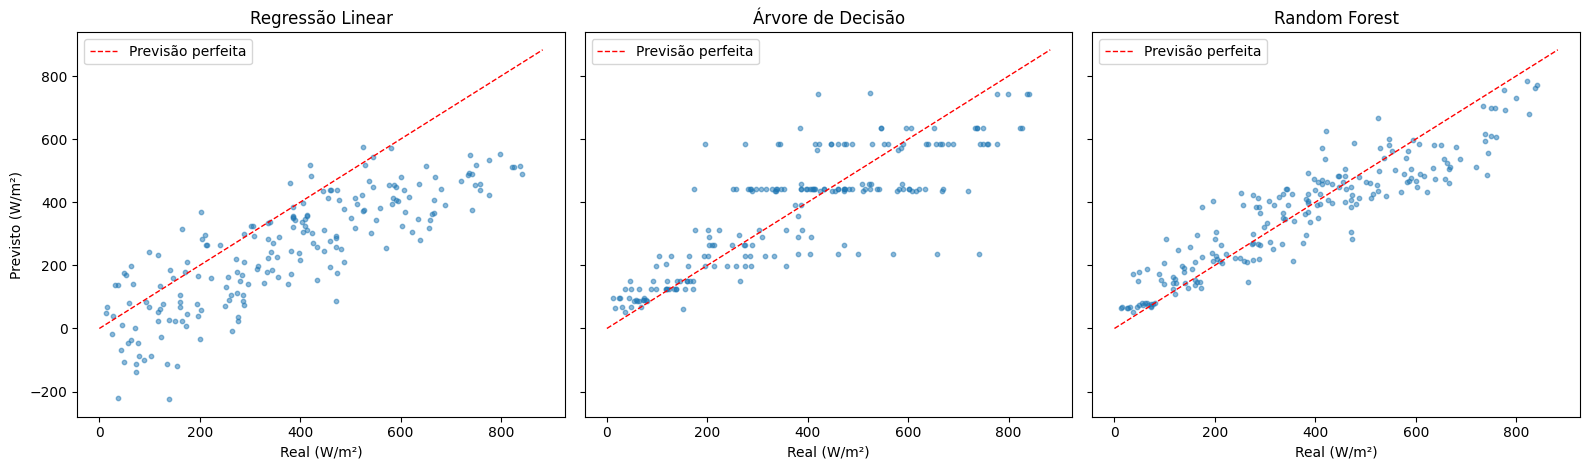

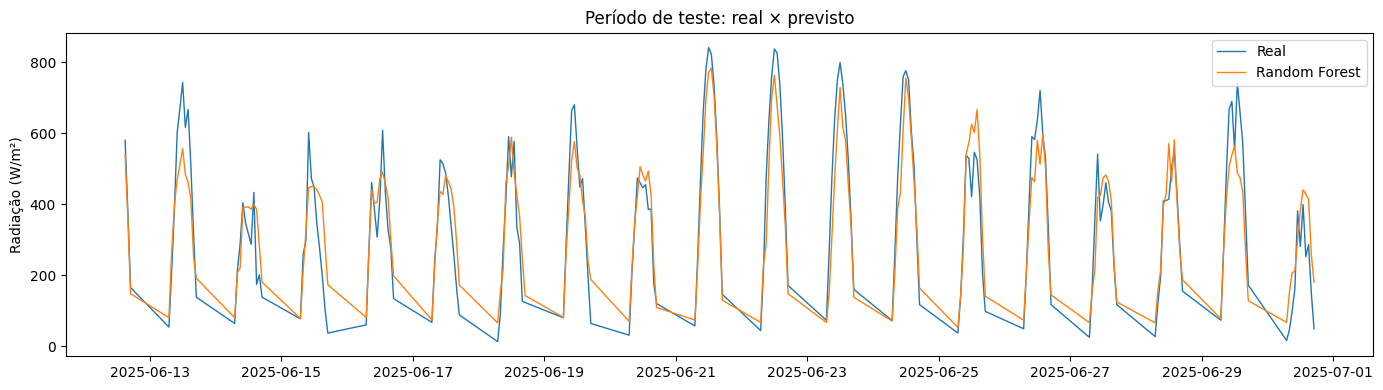

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
limite = [0, max(y_teste_reg.max(), max(p.max() for p in previsoes_reg.values())) * 1.05]

for ax, (nome, y_pred) in zip(axes, previsoes_reg.items()):
    ax.scatter(y_teste_reg, y_pred, s=10, alpha=0.5)
    ax.plot(limite, limite, "r--", linewidth=1, label="Previsão perfeita")
    ax.set_title(nome)
    ax.set_xlabel("Real (W/m²)")
    ax.legend()
axes[0].set_ylabel("Previsto (W/m²)")

plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(meteo["data_hora"].iloc[corte:], y_teste_reg.values, label="Real", linewidth=1)
plt.plot(meteo["data_hora"].iloc[corte:], previsoes_reg["Random Forest"], label="Random Forest", linewidth=1)
plt.ylabel("Radiação (W/m²)")
plt.title("Período de teste: real × previsto")
plt.legend()
plt.tight_layout()
plt.show()

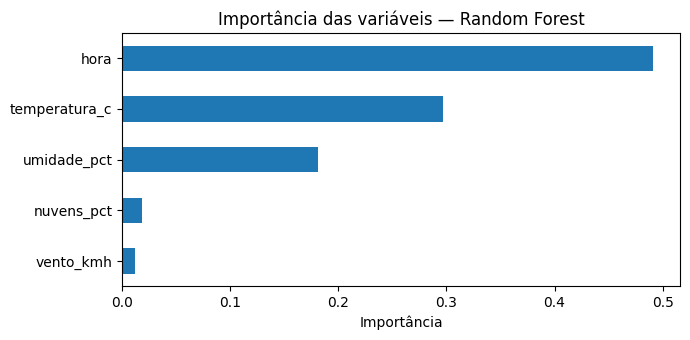

In [58]:
importancias = pd.Series(
    regressores["Random Forest"].feature_importances_, index=entradas
).sort_values()

importancias.plot(kind="barh", figsize=(7, 3.5), title="Importância das variáveis — Random Forest")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

### 5. Interpretação e conclusões

O **Random Forest** apresentou o melhor desempenho (MAE 69,3 W/m²; R² 0,832), seguido pela Árvore de Decisão (MAE 90,9 W/m²; R² 0,678). A **Regressão Linear** teve o pior resultado (MAE 145,2 W/m²; R² 0,360) porque a relação entre hora e radiação não é linear: a radiação cresce pela manhã, atinge o máximo perto do meio-dia e decresce à tarde. Um modelo linear só representa tendências monotônicas, enquanto os modelos baseados em árvores dividem o eixo horário em faixas e capturam essa curva.

A **hora** foi a variável de maior importância no Random Forest, pois determina a elevação solar e, portanto, a radiação disponível em céu limpo. As demais variáveis explicam os desvios em relação a esse padrão diário. O teste cobre de 12 a 30 de junho, período de radiação média inferior à de abril, o que impõe ao modelo uma leve mudança de distribuição em relação ao treino.

Estimar radiação **não equivale a prever geração elétrica**. A radiação (W/m²) é a potência solar incidente por unidade de área em um plano horizontal. A energia produzida (kWh) depende ainda da área e da eficiência dos módulos, da inclinação e orientação dos painéis, da temperatura das células, de sombreamento e sujeira, e das perdas no inversor e no cabeamento. Além disso, os dados vêm de modelos de reanálise, não de medições em uma usina.

In [59]:
meteo_orange = pd.read_csv("meteo_regressao_orange.csv")
corte_orange = int(len(meteo_orange) * 0.8)

meteo_orange.iloc[:corte_orange].to_csv("meteo_treino_orange.csv", index=False, encoding="utf-8-sig")
meteo_orange.iloc[corte_orange:].to_csv("meteo_teste_orange.csv", index=False, encoding="utf-8-sig")
print("Arquivos para o Orange salvos.")

Arquivos para o Orange salvos.


# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)